# Assignment 4: Customer Segmentation with Clustering

**Student Name:** Alex Tomasella

**Date:** Feb. 19th, 2026
---

## Assignment Overview

You've been hired as a data science consultant by a UK-based online gift retailer. They're spending the same amount on marketing to all customers regardless of value. Your task: segment their customer base using transaction data from 2009-2011, identify distinct customer groups, and provide actionable recommendations for each segment.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [3]:
# Load the Online Retail II dataset
# TODO: Load online_retail_II.csv from the data folder
df = pd.read_csv("data/online_retail_II.csv")  # Replace with pd.read_csv()

# Display basic information
# TODO: Display the first few rows and basic info about the dataset
print(df.head())
print(df.info())
print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Dataset shape: {df.shape if df is not None else 'Not loaded'}")
print(f"Date range: [Check InvoiceDate column]")
print("="*80)

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      106737

---
## Step 2: Aggregate Transaction Data to Customer-Level RFM Features

### Clean Transaction Data

Before aggregating to customer-level, clean the transaction data:
- Remove rows with missing Customer ID
- Remove returns (negative Quantity)
- Create TotalSpend column (Quantity × Price)
- Convert InvoiceDate to datetime

In [4]:
# Clean the data
# TODO: Remove missing Customer IDs
df = df.dropna(subset=['Customer ID'])


# TODO: Remove negative quantities (returns)
df = df[df['Quantity'] > 0]


# TODO: Create TotalSpend column
df['TotalSpend'] = df['Quantity'] * df['Price']


# TODO: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\n" + "="*80)
print("CHECKPOINT: After data cleaning")
print(f"Remaining transactions: {len(df) if df is not None else 'N/A'}")
print(f"Unique customers: {df['Customer ID'].nunique() if df is not None else 'N/A'}")
print("="*80)


CHECKPOINT: After data cleaning
Remaining transactions: 805620
Unique customers: 5881


### Calculate RFM Features for Each Customer

Create three features for each customer:
- **Recency**: Days since last purchase (use December 10, 2011 as reference date)
- **Frequency**: Total number of unique invoices
- **Monetary**: Total amount spent

In [5]:
# Set reference date for recency calculation
reference_date = pd.to_datetime('2011-12-10')

# TODO: For each Customer ID, calculate:
# - Recency: (reference_date - max(InvoiceDate)).days
# - Frequency: count of unique Invoice numbers
# - Monetary: sum of TotalSpend

rfm_df = df.groupby('Customer ID').apply(
    lambda x: pd.Series({
        'Recency': (reference_date - x['InvoiceDate'].max()).days,
        'Frequency': x['Invoice'].nunique(),
        'Monetary': x['TotalSpend'].sum()
    })
)
print("\n" + "="*80)
print("CHECKPOINT: RFM Features Created")
if rfm_df is not None:
    print(f"Number of customers: {len(rfm_df)}")
    print(f"\nRFM Summary Statistics:")
    print(rfm_df.describe())
print("="*80)


CHECKPOINT: RFM Features Created
Number of customers: 5881

RFM Summary Statistics:
           Recency    Frequency       Monetary
count  5881.000000  5881.000000    5881.000000
mean    200.992858     6.287196    3017.076888
std     209.489651    13.012879   14734.128619
min       0.000000     1.000000       0.000000
25%      25.000000     1.000000     347.800000
50%      95.000000     3.000000     897.620000
75%     379.000000     7.000000    2304.180000
max     738.000000   398.000000  608821.650000


---
## Step 3: Standardize Features and Determine Optimal k

### Standardize RFM Features

K-means is sensitive to feature scale, so standardize features to mean=0, std=1

In [6]:
# TODO: Use StandardScaler to standardize Recency, Frequency, and Monetary
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
if rfm_scaled is not None:
    print(f"Scaled features shape: {rfm_scaled.shape}")
    print(f"Mean of scaled features: {rfm_scaled.mean(axis=0)}")
    print(f"Std of scaled features: {rfm_scaled.std(axis=0)}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled features shape: (5881, 3)
Mean of scaled features: [ 9.18232408e-17 -2.77886123e-17 -2.65804118e-17]
Std of scaled features: [1. 1. 1.]


### Elbow Method: Test k from 2 to 10

Calculate inertia (within-cluster sum of squares) for different values of k

In [18]:
# TODO: Test k values from 2 to 10
# For each k:
#   - Train KMeans(n_clusters=k, random_state=42)
#   - Store inertia value'
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)


print("\n" + "="*80)
print("CHECKPOINT: Elbow Method Calculated")
print(f"Tested k values: {list(k_range)}")
print("="*80)


CHECKPOINT: Elbow Method Calculated
Tested k values: [2, 3, 4, 5, 6, 7, 8, 9, 10]


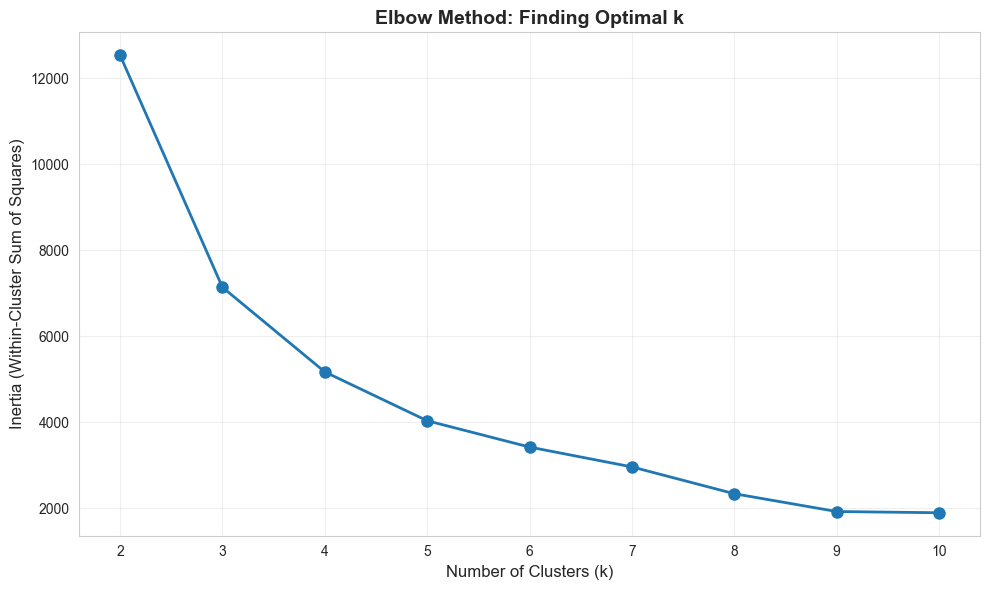

In [9]:
# TODO: Plot the elbow curve
# x-axis: k values
# y-axis: inertia

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method: Finding Optimal k', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Silhouette Score Analysis

Calculate silhouette scores to validate cluster quality

In [17]:
# TODO: Calculate silhouette scores for k from 2 to 10
# For each k:
#   - Train KMeans
#   - Calculate silhouette_score(rfm_scaled, labels)

silhouette_scores = []

for k in k_range:
    # Train k-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    # Calculate silhouette score
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
print(silhouette_scores)

print("\n" + "="*80)
print("CHECKPOINT: Silhouette Scores Calculated")
print("="*80)

[0.916381407089036, 0.5803392830229628, 0.5905519032604194, 0.6030151758528873, 0.5510572510415608, 0.5492536280776511, 0.5423113756102343, 0.5355018206708511, 0.5022035081915487]

CHECKPOINT: Silhouette Scores Calculated


C:\Users\aatra\AppData\Local\Temp\ipykernel_18724\296156397.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


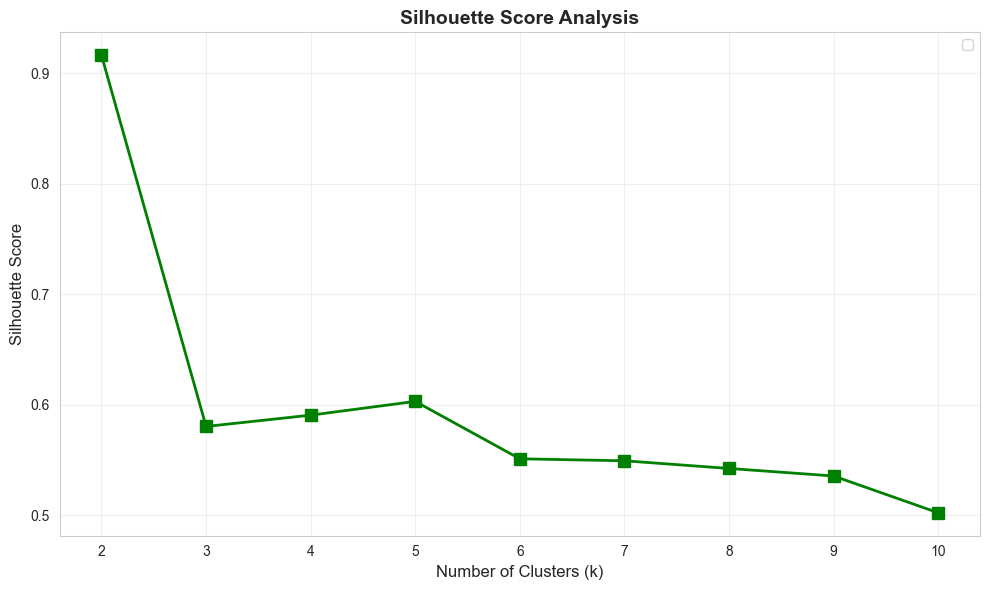

In [16]:
# TODO: Plot silhouette scores
# x-axis: k values
# y-axis: silhouette score
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Select Optimal k

**Your k selection justification (write 2-3 sentences):**

[Based on the elbow plot and silhouette scores, explain why you chose your k value. What did you observe at the elbow point? What were the silhouette scores like for different k values?]

In [ ]:
# Based on the graphs and scores, I would chose k=5. the elbow cure shows huge improvement from 2 -> 3, and the big improvement from 3 -> 4, but after 4, the improvement gets minimal. The silhouette score is super high at 2, but that is not enough groups, but it is second highest at 5. All of the k values stay above .5 which suggests it is a reasonable structure.  

In [15]:
# TODO: Set your chosen k value
optimal_k = 5  # Replace with your chosen k (e.g., 4, 5, or 6)

print(f"Chosen k value: {optimal_k}")

Chosen k value: 5


---
## Step 4: Train K-Means Model and Visualize Segments

### Train Final K-Means Model

In [19]:
# TODO: Train KMeans with your optimal_k and random_state=42
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)  # Replace with trained model
kmeans.fit(rfm_scaled)

# TODO: Add cluster labels to rfm_df
rfm_df['Cluster'] = kmeans.labels_

print("\n" + "="*80)
print("CHECKPOINT: K-Means Model Trained")
print(f"Number of clusters: {optimal_k}")
if 'Cluster' in rfm_df.columns:
    print(f"\nCluster sizes:")
    print(rfm_df['Cluster'].value_counts().sort_index())
print("="*80)


CHECKPOINT: K-Means Model Trained
Number of clusters: 5

Cluster sizes:
Cluster
0    1920
1    3579
2      24
3     354
4       4
Name: count, dtype: int64


### Visualize Customer Segments

Create a 2D scatter plot showing Frequency vs Monetary, colored by cluster

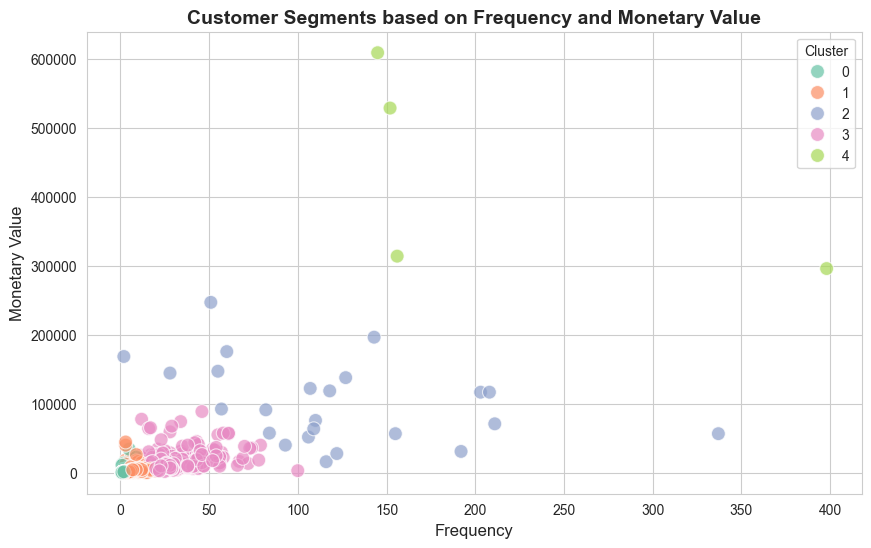

In [20]:
# TODO: Create scatter plot
# x-axis: Frequency
# y-axis: Monetary
# color: Cluster
# Include legend

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', s=100, alpha=0.7)
plt.title('Customer Segments based on Frequency and Monetary Value', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Monetary Value', fontsize=12)
plt.legend(title='Cluster', loc='upper right')


### Calculate Cluster Centers

Show the mean RFM values for each cluster

In [21]:
# TODO: Calculate mean Recency, Frequency, and Monetary for each cluster
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']]  # Replace with grouped DataFrame

print("\n" + "="*80)
print("CLUSTER CENTERS (Mean RFM Values)")
print("="*80)
# TODO: Display cluster_summary
print(cluster_summary.mean())

print("="*80)


CLUSTER CENTERS (Mean RFM Values)
            Recency   Frequency       Monetary
Cluster                                       
0        470.880729    2.164583     754.603699
1         74.981280    5.217100    1953.383557
2         21.833333  119.833333  100927.043417
3         25.579096   29.435028   14502.367551
4          2.750000  212.750000  436835.792500


---
## Step 5: Interpret Segments and Provide Business Recommendations

### Segment 0: Lost Customers

**Customer Profile (3-5 sentences):**

The segment is shown by low recency, high purchase frequency, and medium monetary value. The R value = 470, F value = 2, and the M value = 754 (all rounded down). The people in this group have no made a purchase in awhile and show low engagement compared to the other clusters. They do not have very much business value. Their purchasing patterns are people who do not purchase often. 


[Describe this segment's characteristics. What are their R, F, M values? How do they differ from other segments? What business value do they represent? What are their purchasing patterns?]

In [24]:
# TODO: Calculate detailed statistics for Segment 0
# Show mean, median, min, max for R, F, M

segment_0 = rfm_df[rfm_df['Cluster'] == 0]
segment_0_stats = segment_0[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

print(segment_0_stats)

        Recency  Frequency  Monetary
mean     470.88       2.16    754.60
median   434.00       1.00    379.18
min      267.00       1.00      0.00
max      738.00      29.00  34095.26


### Segment 1: [Occasional Customers]

**Customer Profile (3-5 sentences):**

This group has moderate recency (75), medium frequency (5), and decent monetary value (1953). Customers spend sporadically and maintain some engagement. Compared to the high segemnts, they have a low mentary value but still help toward the revenue. 

In [25]:
# TODO: Calculate detailed statistics for Segment 1
segment_1 = rfm_df[rfm_df['Cluster'] == 1]
segment_1_stats = segment_1[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

print(segment_1_stats)

        Recency  Frequency  Monetary
mean      74.98       5.22   1953.38
median    49.00       4.00   1154.47
min        0.00       1.00      0.00
max      283.00      20.00  44534.30


### Segment 2: [Loyal]

**Customer Profile (3-5 sentences):**

[This group has low recency, high frequency, and high monetary value. They purchase more consistent then the other groups and remain active within the company. This shows their spending habits which is often and their loyalty. . Thet show stability and are a predictable source of revenue.   ]

In [ ]:
# TODO: Calculate detailed statistics for Segment 2
segment_2 = rfm_df[rfm_df['Cluster'] == 2]
segment_2_stats = segment_2[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

print(segment_2_stats)

        Recency  Frequency   Monetary
mean      21.83     119.83  100927.04
median     3.00     109.50   91770.92
min        0.00       2.00   15972.79
max      372.00     337.00  246973.09


### [Continue for remaining segments]

[Add sections for Segment 3, 4, etc. depending on your chosen k]

### Segment 3: [High Value]

**Customer Profile (3-5 sentences):**

[This group shows low recency, high frequency, and  high monetary. These are the customers who make big purchases and generate a lot of revenue for the company.  There do not seem to be a lot of customers in this group. Compared to the loyal customers, they buy less often but seem to spend more per transaction.]

In [27]:
segment_3 = rfm_df[rfm_df['Cluster'] == 3]
segment_3_stats = segment_3[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

print(segment_3_stats)

        Recency  Frequency  Monetary
mean      25.58      29.44  14502.37
median     9.00      26.00  10504.88
min        0.00      11.00   1820.44
max      497.00     100.00  88704.32


### Segment 4: [Champion Customers]

**Customer Profile (3-5 sentences):**

These people are described with very low recency, super high frequency, and super high monetary value. They purchase often and purchase expensive things. They are very loyal customers. Compared to the other segments, they generate the most revenue and are consistent. 

In [28]:
segment_4 = rfm_df[rfm_df['Cluster'] == 4]
segment_4_stats = segment_4[['Recency', 'Frequency', 'Monetary']].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

print(segment_4_stats)

        Recency  Frequency   Monetary
mean       2.75     212.75  436835.79
median     1.00     154.00  421274.44
min        0.00     145.00  295972.63
max        9.00     398.00  608821.65


---
## Business Recommendations

### Recommendation 1: [Champion Retention]

**Which segment(s) does this target?** [Champion Customers]

**Recommendation (3-5 sentences):**

I think the biggest thing the company should do is make sure the champion customers stay. A way to do this could be some sort of rewards programs that rewards you for spending more money so that the champion customers would get rewards for their loyalty. The marketing strategy could be just through an app or texts and flyers ins tore or on the website. This would work for this segment because of the amount of revenue this group brings in. 

[Provide a specific, actionable recommendation directly tied to your cluster findings. What marketing strategy should the company implement? What channels should they use? What offers or messaging would work? Why will this work for this segment?]

### Recommendation 2: [Occasional Solution]

**Which segment(s) does this target?** [Occasional Customers]

**Recommendation (3-5 sentences):**

The company could run promotions to increase the frequency of this group. Maybe do discounts that expire to try and have them use it soon or reminders on their phone through messaging. The hope of the strategy is to make them become more consistent customers increasing revenue. 

### Recommendation 3: [Rengagement]

**Which segment(s) does this target?** [Lost  Customers]

**Recommendation (3-5 sentences):**

[The company can launch a campaign that targets this group. Similiar to the occasional promotion but more focused on emotion saying things like "we miss you here" messages and things that spark their interest again. ]

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - RFM features properly calculated
   - Elbow method and silhouette score visualizations
   - Written justification for your k selection
   - Customer segment scatter plot
   - Descriptive names and profiles for each segment
   - Three specific business recommendations
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed customer segmentation assignment'
git push
```

Submit your GitHub repository link on the course platform.